# Unit 5 — 02: Automated Retraining Pipeline

**What you will do:** Build a full retraining decision loop — detect when to retrain, run retraining, compare old vs new model, and promote the winner.

**Why it matters:** A model deployed today will drift over time. Without automated retraining, you are shipping a product whose quality silently degrades.

**How to run:** Python 3.10+. Run cells in order.

## 🔗 Where this fits

**Builds on:** Course 05 (AIAT 115) — Unit 5, lesson 05 "05. Production Pipelines" — a scheduled pipeline with explicit logging and error handling; here the pipeline's job is to decide *whether* to retrain at all, then compare the challenger against the champion before either reaches users.

---

## 📰 Tay: what automatic retraining looks like with no gate

Microsoft launched **Tay**, a conversational bot that learned from its interactions, on Twitter on **23 March 2016**. Users quickly discovered that the learning loop had no filter between "input from the internet" and "model behaviour", and fed it deliberately abusive material. Microsoft took Tay offline **about 16 hours after launch**. In the company's public apology, Peter Lee wrote that *"in the first 24 hours of coming online, a coordinated attack by a subset of people exploited a vulnerability in Tay"* — and that although many kinds of abuse had been anticipated, this one had not.

Tay is the purest available demonstration of this notebook's subject. Retraining on production data is not automatically an improvement; **it is a channel through which the world modifies your model**, and everything downstream of that channel depends on what you check before promotion. A retraining pipeline without a validation gate and a champion/challenger comparison is a mechanism for making a model worse, automatically, on a schedule.

**What goes wrong without this lesson.** Two symmetrical failures. Retrain too rarely and the model quietly decays as its world drifts (Zillow, Unit 1 notebook 06). Retrain automatically with no gate and you promote a model trained on corrupted, anomalous or adversarial data before anyone notices the data was bad. The loop below — detect, retrain, compare, promote or reject — exists to sit between those two mistakes.

## Section 1 — When to Retrain

Three standard triggers for retraining in production:

| Trigger | Condition | Example |
|---|---|---|
| **Scheduled** | Fixed cadence (weekly/monthly) | Every Sunday at 2am regardless of metrics |
| **Performance-based** | Accuracy drops below a threshold | Accuracy < 85% triggers retraining |
| **Drift-detected** | Input distribution has shifted | KS test p-value < 0.05 on feature distributions (0.05 is a threshold *you* pick — see lesson 04) |

In practice, you combine all three: schedule keeps the model fresh, and drift/performance triggers catch sudden changes.

## Section 2 — Simulate a Drift Scenario

Train on clean iris data. Evaluate on a noisy (shifted) version. Watch accuracy drop.

In [1]:
# WHAT: train model v1, then measure how much accuracy it loses on drifted data.
# WHY: this accuracy gap is the problem retraining exists to fix — we create it
# deliberately so the pipeline below has something real to react to.
import numpy as np
import pathlib
import json
import joblib
from typing import Dict, Tuple, List

from sklearn.datasets import load_iris
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from scipy import stats as sp_stats

rng = np.random.default_rng(42)

iris = load_iris()
X, y = iris.data, iris.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the initial production model
model_v1 = RandomForestClassifier(n_estimators=50, random_state=42)
model_v1.fit(X_train, y_train)
acc_original = model_v1.score(X_test, y_test)
print(f"Model v1 accuracy on clean test data:   {acc_original:.3f}")

# Simulate drift: add substantial noise to represent new production data
X_test_drifted = X_test + rng.normal(loc=0.5, scale=0.8, size=X_test.shape)
acc_drifted = model_v1.score(X_test_drifted, y_test)
print(f"Model v1 accuracy on drifted test data: {acc_drifted:.3f}")
print(f"Accuracy drop: {acc_original - acc_drifted:.3f}")

Model v1 accuracy on clean test data:   1.000
Model v1 accuracy on drifted test data: 0.644
Accuracy drop: 0.356


## Section 3 — The Retraining Decision Function

`should_retrain()` centralizes all trigger logic. It returns `True` and a human-readable reason, or `False` if no trigger fires.

In [2]:
# WHAT: define should_retrain() — two independent triggers: accuracy below
# threshold OR drift score above threshold.
# WHY: accuracy needs labels (slow to arrive); drift needs only inputs (instant).
# Together they catch problems whether or not ground truth is available yet.
def should_retrain(
    current_accuracy: float,
    accuracy_threshold: float,
    drift_score: float,
    drift_threshold: float,
) -> Tuple[bool, str]:
    """
    Returns (True, reason) if retraining is needed, else (False, 'OK').
    drift_score: KS statistic (0-1). Higher = more drift.
    """
    if current_accuracy < accuracy_threshold:
        return True, f"Accuracy {current_accuracy:.3f} < threshold {accuracy_threshold:.3f}"
    if drift_score > drift_threshold:
        return True, f"Drift score {drift_score:.3f} > threshold {drift_threshold:.3f}"
    return False, "OK — no trigger fired"


# Compute a KS drift score on the first feature
ks_stat, ks_pvalue = sp_stats.ks_2samp(X_test[:, 0], X_test_drifted[:, 0])
print(f"KS drift score on feature 0: {ks_stat:.3f}  (p={ks_pvalue:.4f})")

# Four scenarios exercise every branch: healthy, low accuracy, drift, both.
scenarios = [
    (acc_original, 0.85, ks_stat, 0.30, "Normal operation"),
    (acc_drifted,  0.85, ks_stat, 0.30, "Low accuracy"),
    (acc_original, 0.85, 0.40,    0.30, "High drift"),
    (acc_drifted,  0.85, 0.40,    0.30, "Both triggers"),
]

print("\n{:<25} {:<10} {}".format("Scenario", "Retrain?", "Reason"))
print("-" * 70)
for acc, acc_thr, drift, drift_thr, label in scenarios:
    retrain, reason = should_retrain(acc, acc_thr, drift, drift_thr)
    print(f"{label:<25} {str(retrain):<10} {reason}")

KS drift score on feature 0: 0.267  (p=0.0813)

Scenario                  Retrain?   Reason
----------------------------------------------------------------------
Normal operation          False      OK — no trigger fired
Low accuracy              True       Accuracy 0.644 < threshold 0.850
High drift                True       Drift score 0.400 > threshold 0.300
Both triggers             True       Accuracy 0.644 < threshold 0.850


## Section 4 — The Retraining Pipeline Function

`retrain_pipeline()` trains a new model, evaluates it, and saves it with a versioned filename.

In [3]:
# WHAT: the retraining pipeline itself — train on new data, validate, save a
# VERSIONED artifact, return metrics.
# WHY: retraining must be a repeatable function, not a manual ritual; versioned
# files mean any model can be rolled back to by name.
MODEL_DIR = pathlib.Path("/tmp/models")
MODEL_DIR.mkdir(exist_ok=True)


def retrain_pipeline(
    new_data: Tuple[np.ndarray, np.ndarray],
    validation_data: Tuple[np.ndarray, np.ndarray],
    version: int = 1,
) -> Tuple[Dict, object]:
    """
    Train a new model on new_data, evaluate on validation_data.
    Save to a versioned file and return (metrics, model).
    """
    X_new, y_new = new_data
    X_val, y_val = validation_data

    new_model = RandomForestClassifier(n_estimators=100, random_state=42)
    new_model.fit(X_new, y_new)

    val_accuracy = float(new_model.score(X_val, y_val))
    model_path = MODEL_DIR / f"model_v{version}.pkl"
    joblib.dump(new_model, model_path)

    metrics = {
        "version": version,
        "val_accuracy": round(val_accuracy, 4),
        "training_samples": len(X_new),
        "model_path": str(model_path),
    }
    print(f"  Saved model v{version} -> {model_path}  (val_acc={val_accuracy:.3f})")
    return metrics, new_model


# Simulate collecting new data from production (with some drift corrected)
X_new_train = X_train + rng.normal(loc=0.2, scale=0.3, size=X_train.shape)
y_new_train = y_train

print("Running retrain pipeline v2...")
metrics_v2, model_v2 = retrain_pipeline(
    new_data=(X_new_train, y_new_train),
    validation_data=(X_test, y_test),
    version=2,
)

Running retrain pipeline v2...
  Saved model v2 -> /tmp/models/model_v2.pkl  (val_acc=0.911)


## Section 5 — Full Retraining Loop: Detect → Retrain → Compare → Promote

> **Read the numbers carefully.** Below, the champion (v1) accuracy is its score on the *drifted* production data (which is why it looks low), while the challenger (v2) is scored on the *clean* validation set. That makes v2 look dramatically better and it gets promoted. In a real champion/challenger test you must score **both models on the same held-out set** to compare fairly — here we show the simplified version so the promotion logic is easy to follow.

Production accuracy (on drifted data): 0.644


Retrain? True — Accuracy 0.644 < threshold 0.850

--- Starting retraining ---
  Saved model v2 -> /tmp/models/model_v2.pkl  (val_acc=0.978)

--- Champion vs Challenger ---
  v1 (champion):  0.644
  v2  (challenger): 0.978
  PROMOTED v2 to production.


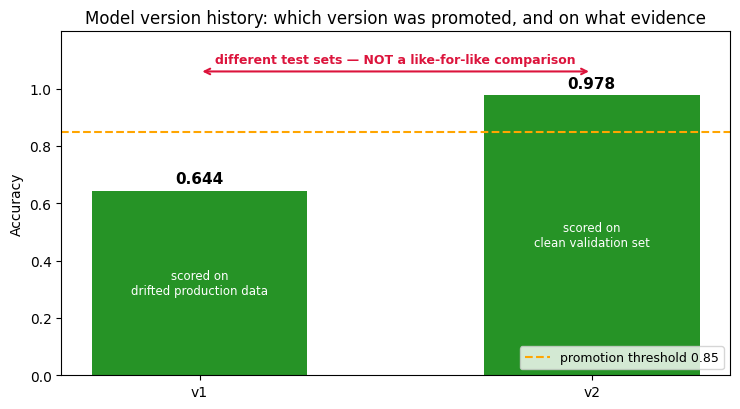

In [4]:
# WHAT: the full loop — detect the trigger, retrain a challenger, and promote it
# only if it beats the current champion on validation data.
# WHY: champion/challenger is the safety net: retraining can produce a WORSE
# model, and this comparison is what keeps it out of production.
import matplotlib.pyplot as plt

# Current production state
current_model = model_v1
current_version = 1
# Simulate: the model is evaluated on recent (drifted) production data
current_accuracy = acc_drifted

ACCURACY_THRESHOLD = 0.85
DRIFT_THRESHOLD = 0.30
# Record WHICH data each score came from — the comparison below is not
# like-for-like, and the figure has to say so.
version_history: List[Dict] = [{"version": 1, "accuracy": acc_drifted, "promoted": True,
                                "eval_set": "drifted production data"}]

print(f"Production accuracy (on drifted data): {current_accuracy:.3f}")
retrain_needed, reason = should_retrain(current_accuracy, ACCURACY_THRESHOLD, ks_stat, DRIFT_THRESHOLD)
print(f"Retrain? {retrain_needed} — {reason}")

# The trigger fired: build a challenger from old data plus recent labeled samples.
if retrain_needed:
    print("\n--- Starting retraining ---")
    # In practice, new_train combines old training data + recent labeled production data
    X_combined = np.vstack([X_train, X_test_drifted[:20]])
    y_combined = np.concatenate([y_train, y_test[:20]])

    new_version = current_version + 1
    metrics_new, candidate_model = retrain_pipeline(
        new_data=(X_combined, y_combined),
        validation_data=(X_test, y_test),
        version=new_version,
    )
    new_accuracy = metrics_new["val_accuracy"]

    print(f"\n--- Champion vs Challenger ---")
    print(f"  v{current_version} (champion):  {current_accuracy:.3f}")
    print(f"  v{new_version}  (challenger): {new_accuracy:.3f}")

    if new_accuracy > current_accuracy:
        current_model = candidate_model
        current_version = new_version
        current_accuracy = new_accuracy
        version_history.append({"version": new_version, "accuracy": new_accuracy,
                                "promoted": True, "eval_set": "clean validation set"})
        print(f"  PROMOTED v{new_version} to production.")
    else:
        version_history.append({"version": new_version, "accuracy": new_accuracy,
                                "promoted": False, "eval_set": "clean validation set"})
        print(f"  REJECTED v{new_version} — challenger did not beat champion.")

# Green = promoted, red = rejected. Every bar is labelled with the dataset it
# was scored on, because that is what decides whether this chart means anything.
versions   = [v["version"]   for v in version_history]
accuracies = [v["accuracy"]  for v in version_history]
eval_sets  = [v["eval_set"]  for v in version_history]
colors     = ["green" if v["promoted"] else "red" for v in version_history]

fig, ax = plt.subplots(figsize=(7.5, 4.2))
bars = ax.bar([f"v{v}" for v in versions], accuracies, color=colors, alpha=0.85, width=0.55)
ax.axhline(ACCURACY_THRESHOLD, color="orange", linestyle="--",
           label=f"promotion threshold {ACCURACY_THRESHOLD}")
for bar, acc, eset in zip(bars, accuracies, eval_sets):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.025, f"{acc:.3f}",
            ha="center", fontsize=11, fontweight="bold")
    ax.text(bar.get_x() + bar.get_width() / 2, acc / 2, f"scored on\n{eset}",
            ha="center", va="center", fontsize=8.5, color="white")
# The warning belongs ON the picture, not only in the text above it.
if len(set(eval_sets)) > 1:
    ax.annotate("", xy=(0, 1.06), xytext=(1, 1.06),
                arrowprops=dict(arrowstyle="<->", color="crimson", lw=1.5))
    ax.text(0.5, 1.09, "different test sets — NOT a like-for-like comparison",
            ha="center", fontsize=9, color="crimson", fontweight="bold")
ax.set_title("Model version history: which version was promoted, and on what evidence")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1.2)
ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.savefig("/tmp/retrain_versions.png", dpi=72)
plt.show()

**Read the figure.** Two bars, both green: v1 was the incumbent and v2 was promoted over it. v1's bar is labelled *drifted production data* and v2's is labelled *clean validation set* — the red arrow across the top says the rest. The 0.334 gap you see is not a measurement of which model is better; it is mostly a measurement of **which data each one was asked about**. v1 sits below the orange promotion threshold and v2 sits well above it, and that is exactly the shape a rigged comparison produces.

**What it proves.** The promotion logic ran correctly and the conclusion is still unsupported. A champion/challenger gate is only a gate if both models are scored on the *same* held-out set drawn from the traffic they will actually serve — question 2 in the Discuss cell asks you to write that rule.

## 💬 Discuss

One printed number should stop you. The model's accuracy on drifted data fell from **1.000 to 0.644** — a collapse of 0.356. And the KS drift test on feature 0 returned **0.267 with p = 0.0813**: *not* significant at the conventional 0.05, which means **the drift trigger would not have fired**. Only the accuracy trigger caught this, and accuracy needs labels.

1. Given that result, how much would you trust a drift-only retraining trigger on a model whose labels arrive three weeks late? What would you actually deploy — and how would you justify the delay to a business owner?
2. The notebook says plainly that the champion was scored on drifted data and the challenger on clean data, so the promotion was decided by an unfair comparison. Rewrite the promotion rule in one sentence so that it is fair. What data would you need that this notebook does not have?
3. Consider the opposite failure — Tay's. Design the smallest set of checks you would put between "new data arrives" and "retraining starts". Not between retraining and promotion: *before training*. What are you checking, and what does each check cost you in delay?

## Section 6 — Scheduling Retraining

In production you want `check_and_retrain()` to run automatically. Two options:

In [5]:
# --- Option A: APScheduler (install with: pip install apscheduler) ---
try:
    from apscheduler.schedulers.background import BackgroundScheduler

    def check_and_retrain():
        print("[Scheduler] Running retrain check...")
        # In production: fetch current metrics from monitoring, run should_retrain(), etc.

    scheduler = BackgroundScheduler()
    scheduler.add_job(check_and_retrain, "interval", hours=24)
    # scheduler.start()  # uncomment to actually start the scheduler
    print("APScheduler configured: check_and_retrain() will run every 24 hours.")

except ImportError:
    print("APScheduler not installed. Showing threading.Timer alternative:")

    # --- Option B: threading.Timer (stdlib, no install needed) ---
    import threading

    def schedule_retrain_check(interval_seconds: float = 86400.0):
        """Run check_and_retrain every interval_seconds using a recurring Timer."""
        def _run():
            print("[Timer] Running retrain check...")
            schedule_retrain_check(interval_seconds)  # reschedule

        timer = threading.Timer(interval_seconds, _run)
        timer.daemon = True  # won't block program exit
        # timer.start()  # uncomment to actually start
        return timer

    timer = schedule_retrain_check(interval_seconds=5.0)  # 5s demo; use 86400 in production
    print(f"threading.Timer configured (interval=5s demo). Start with timer.start()")

print("\nProduction cron equivalent (in crontab):")
print("  0 2 * * 0   python /opt/ml/retrain.py   # every Sunday at 2am")

APScheduler not installed. Showing threading.Timer alternative:
threading.Timer configured (interval=5s demo). Start with timer.start()

Production cron equivalent (in crontab):
  0 2 * * 0   python /opt/ml/retrain.py   # every Sunday at 2am


## 👁️ See it — decay, and what each retraining policy buys back

Everything so far happened at a single moment: one accuracy drop, one trigger, one promotion. The decision that actually matters is a *policy* — a rule you will run for a year. Below, the same drifting stream of production traffic is served for **24 weeks** by three policies:

- **never retrain** — ship v1 and walk away;
- **scheduled** — retrain every 4 weeks on the last two weeks of labelled traffic plus the original training set;
- **drift-triggered** — retrain only when the KS statistic against the reference exceeds 0.30 (and reset the reference after each retrain, as you must, or it fires forever).

Drift here is a steady weekly offset added to the iris features — a sensor slowly going out of calibration, which is the drift shape a retrain can actually repair.

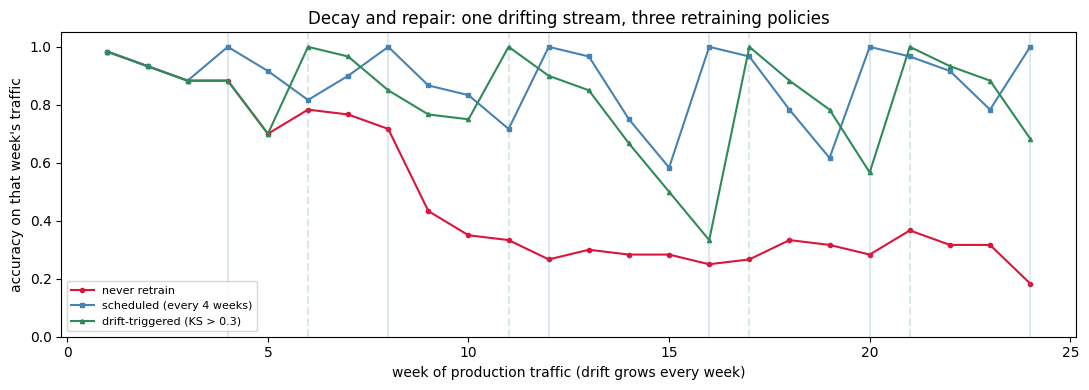

policy                    mean acc  worst week  retrains
--------------------------------------------------------
never retrain                0.481       0.183         0
scheduled (4 weeks)          0.883       0.583         6
drift-triggered              0.821       0.333         4

Scheduled retrains fired in weeks: [4, 8, 12, 16, 20, 24]
Drift-triggered retrains fired in weeks: [6, 11, 17, 21]


In [6]:
# WHAT: run 24 simulated weeks of drifting traffic under three retraining
# policies and plot the accuracy each one delivers, week by week.
# WHY: one retrain looks like a win in isolation. A policy has to be judged over
# time — including the weeks between retrains, where the model is at its worst.
sim_rng = np.random.default_rng(7)   # own generator: the figure does not depend
                                     # on how many draws earlier cells consumed
WEEKS, BATCH = 24, 60
DRIFT_DIRECTION = np.array([1.0, -0.8, 1.2, 0.6])   # per-week offset per feature
DRIFT_PER_WEEK = 0.10

def production_week(week: int):
    """One week of traffic: real iris rows, offset by that week's accumulated drift."""
    idx = sim_rng.integers(0, len(X_test), size=BATCH)
    Xb = (X_test[idx] + (DRIFT_PER_WEEK * week) * DRIFT_DIRECTION
          + sim_rng.normal(0, 0.10, (BATCH, 4)))
    return Xb, y_test[idx]

weeks_data = [production_week(t) for t in range(WEEKS + 1)]

def fit_forest(Xtr, ytr):
    return RandomForestClassifier(n_estimators=50, random_state=42).fit(Xtr, ytr)

def recent_training_set(t: int):
    """Original training data + the last two weeks of labelled production data."""
    Xr = np.vstack([X_train] + [weeks_data[k][0] for k in (t - 1, t)])
    yr = np.concatenate([y_train] + [weeks_data[k][1] for k in (t - 1, t)])
    return Xr, yr

model_never = fit_forest(X_train, y_train)     # policy 1: frozen at week 0
model_sched = fit_forest(X_train, y_train)     # policy 2: calendar
model_drift = fit_forest(X_train, y_train)     # policy 3: KS trigger
drift_reference = X_train[:, 0].copy()         # what the trigger compares against

acc_never, acc_sched, acc_drift = [], [], []
sched_events, drift_events = [], []

for t in range(1, WEEKS + 1):
    Xb, yb = weeks_data[t]

    if t % 4 == 0:                                    # calendar trigger
        model_sched = fit_forest(*recent_training_set(t))
        sched_events.append(t)

    ks_stat_t, _ = sp_stats.ks_2samp(drift_reference, Xb[:, 0])
    if ks_stat_t > DRIFT_THRESHOLD:                   # drift trigger (0.30)
        model_drift = fit_forest(*recent_training_set(t))
        drift_events.append(t)
        drift_reference = Xb[:, 0].copy()             # reference moves with the model

    acc_never.append(model_never.score(Xb, yb))
    acc_sched.append(model_sched.score(Xb, yb))
    acc_drift.append(model_drift.score(Xb, yb))

weeks = np.arange(1, WEEKS + 1)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(weeks, acc_never, color="crimson",   marker="o", ms=3, label="never retrain")
ax.plot(weeks, acc_sched, color="steelblue", marker="s", ms=3, label="scheduled (every 4 weeks)")
ax.plot(weeks, acc_drift, color="seagreen",  marker="^", ms=3,
        label=f"drift-triggered (KS > {DRIFT_THRESHOLD})")
for t in sched_events:                                   # vertical line = a retrain
    ax.axvline(t, color="steelblue", alpha=0.18)
for t in drift_events:
    ax.axvline(t, color="seagreen", alpha=0.18, linestyle="--")
ax.set_xlabel("week of production traffic (drift grows every week)")
ax.set_ylabel("accuracy on that week's traffic")
ax.set_title("Decay and repair: one drifting stream, three retraining policies")
ax.set_ylim(0, 1.05)
ax.legend(fontsize=8, loc="lower left")
plt.tight_layout()
plt.savefig("/tmp/retrain_policies.png", dpi=72)
plt.show()

print(f"{'policy':<24}{'mean acc':>10}{'worst week':>12}{'retrains':>10}")
print("-" * 56)
for name, accs, events in [("never retrain", acc_never, []),
                           ("scheduled (4 weeks)", acc_sched, sched_events),
                           ("drift-triggered", acc_drift, drift_events)]:
    print(f"{name:<24}{np.mean(accs):>10.3f}{min(accs):>12.3f}{len(events):>10}")
print(f"\nScheduled retrains fired in weeks: {sched_events}")
print(f"Drift-triggered retrains fired in weeks: {drift_events}")

**Read the figure.** The red line is a model nobody maintained: it starts near 1.0, is down to 0.43 by week 9, and from week 10 onwards never climbs above 0.37 again, ending at 0.183 — no better than guessing among three iris classes. The blue and green lines are sawtooths. Each vertical line is a retraining event, and immediately after one the accuracy snaps back to ~1.0; between events it slides down again as the drift keeps accumulating. **The teeth are the cost of the interval**: a model is only as fresh as its last retrain.

**What it proves.** Over 24 weeks the scheduled policy averaged **0.883** and the drift-triggered policy **0.821**, against **0.481** for doing nothing. The calendar beat the detector here — and look at *why*, in the green line: after each retrain the reference window moves to the new data, so the next slow accumulation of drift has to build up all over again before KS crosses 0.30. The detector kept waiting while the model kept decaying, and it fired 4 times where the calendar fired 6.

That is the honest version of the trade-off named in `⚠️ Where this breaks`: a schedule has no threshold to tune and no reference window to get wrong. Make it your baseline, and make the detector prove it adds something — cheaper retrains are only a saving if the weeks in between are still good enough to serve.

## Summary

The retraining decision loop:

1. **Detect** — one of three triggers fires: scheduled interval, accuracy below threshold, or drift score above threshold
2. **Retrain** — train a challenger model on new data (or new + old data combined)
3. **Compare** — evaluate both champion and challenger on the same held-out validation set
4. **Promote or reject** — only swap to the new model if it strictly beats the current one
5. **Schedule** — run this loop automatically with APScheduler, cron, or Airflow

## Self-Check (answer before scrolling back up)

1. **What is the risk of retraining too often?**  
   Each retraining cycle costs compute and engineering time. More critically, if you retrain on very small windows of new data you may overfit to recent noise and reduce generalization. You can also accidentally retrain on corrupt or anomalous data before noticing the problem.

2. **Why compare new model accuracy to the old model before promoting?**  
   A new model trained on more data is not guaranteed to be better. Retraining could produce a worse model if the new data is noisy, mislabeled, or if the training run diverged. Never replace a working model without a side-by-side comparison.

3. **What data do you train the new model on — just new data, or new + old?**  
   Usually a combination. Pure new data risks forgetting earlier patterns (catastrophic forgetting). Pure old data does not fix the drift. The typical approach is a sliding window: the most recent N weeks of labeled data, which includes both old context and recent distribution.

## ⚠️ Where this breaks

- **The drift trigger did not fire when the model broke.** KS on feature 0 returned p = 0.0813 while accuracy fell by 0.356. This is not a bug in the notebook; it is the honest behaviour of statistical drift tests on modest samples, and it is the practical argument behind a 2026 critique (*The Window Dilemma: Why Concept Drift Detection is Ill-Posed*, arXiv 2602.06456), which argues that drift detection as usually framed is ill-posed and that **plain scheduled retraining often outperforms drift-aware methods**. Treat the schedule as your baseline and make drift detection prove it adds something.
- **The champion/challenger comparison here is not fair, and the notebook says so.** v1's 0.644 is its score on drifted data; v2's 0.978 is on a clean validation set. Comparing across different data guarantees the challenger wins. **Both models must be scored on the same held-out set**, and that set must resemble the traffic they will receive.
- **Retraining assumes labels are correct and unbiased. Often they are neither.** If labels come from human review of the model's own alerts, you only ever get labels for cases the model flagged — a feedback loop that trains the next model on the last model's blind spots. If they come from users, they can be attacked, which is the Tay failure in a slower form.
- **The assumption that must hold:** the new data is at least as trustworthy as the old data. Nothing in `retrain_pipeline()` validates the training set. A corrupted upstream feed, a schema change, or a poisoned batch produces a model that trains cleanly, validates cleanly on data from the same corrupted source, and is wrong.
- **Retraining is not free and not always the right response.** Compute, engineering time, a new artifact to audit, and a fresh chance to introduce a regression. If drift comes from a fixable data-pipeline bug — a unit change, a renamed column — retraining bakes the bug into the model. **Diagnose before you retrain.**
- **The cheaper alternative.** For many production models the strongest baseline is unglamorous: retrain on a fixed schedule, on a sliding window of recent labelled data, with a fair champion/challenger gate and a human sign-off. No detector to tune, no threshold to argue about, and a known cadence you can plan around.

## 🔭 State of the field (2026)

The 24-week comparison above lands on the same side as the current evidence: the calendar is the baseline
a detector has to beat, which is exactly the argument of the 2026 critique already cited in
`⚠️ Where this breaks`. What 2026 adds is a third option this loop does not yet consider. Every run of
`retrain_pipeline()` throws away the model it replaced, and Lyu et al. (2025, arXiv:2505.02961) show that
those discarded models are an asset: evaluating model-*selection* mechanisms over a pool of previously
trained models on three large public operations datasets — Google and Alibaba cluster traces and Backblaze
disk statistics — they find that selecting a past model by temporal adjacency can outperform periodic
retraining, while still leaving a measurable gap to the best achievable choice. Read as an instruction:
**keep your old artifacts and version them, because re-selecting one may be cheaper and better than
training a new one.**

That changes only step 2 of the loop. Detect → retrain → compare on the same held-out set → promote or
reject is unchanged, and the gate is still the part that decides whether the automation helps or hurts —
it is what stands between a scheduled pipeline and Tay. Learn the loop here; model selection is a wider
candidate set for the same gate (Gower-Winter et al., 2026, arXiv:2602.06456).

## 📚 References

1. Baylor, D., Breck, E., Cheng, H.-T., et al. (2017). *TFX: A TensorFlow-Based Production-Scale Machine Learning Platform*. KDD. <https://research.google/pubs/tfx-a-tensorflow-based-production-scale-machine-learning-platform/>
2. Sculley, D., Holt, G., Golovin, D., et al. (2015). *Hidden Technical Debt in Machine Learning Systems*. NeurIPS 28. <https://papers.nips.cc/paper_files/paper/2015/hash/86df7dcfd896fcaf2674f757a2463eba-Abstract.html>
3. Shankar, S., Garcia, R., Hellerstein, J. M., & Parameswaran, A. G. (2022). *Operationalizing Machine Learning: An Interview Study*. arXiv. <https://arxiv.org/abs/2209.09125>
4. Gower-Winter, B., Groen, M., & Krempl, G. (2026). *The Window Dilemma: Why Concept Drift Detection is Ill-Posed*. arXiv:2602.06456. <https://arxiv.org/abs/2602.06456>
5. Lyu, Y., Li, H., Li, H., & Hassan, A. E. (2025). *Can We Recycle Our Old Models? An Empirical Evaluation of Model Selection Mechanisms for AIOps Solutions*. arXiv:2505.02961. <https://arxiv.org/abs/2505.02961>
